# Data Exploration Techniques for Glacier Prove Model

### Step 1: Standard Imports

In [4]:
import pandas as pd
from pathlib import Path
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import os

print('Imported')

Imported


In [5]:
# Define your base data directories

base_dir = Path("..") # Assumes notebook is in 'notebooks/'
metadata_dir = base_dir / "data/raw/raw_images/metadata"
image_dir = base_dir / "data/raw/raw_images/raw_images"

print(f"Metadata files found: {len(list(metadata_dir.glob('*.txt')))}")
print(f"Image files found: {len(list(image_dir.glob('*.tif')))}")

Metadata files found: 662
Image files found: 662


### Step 2: Building Metadata DataFrame

In [19]:
def parse_metadata(filepath):
    """Parses a single metadata .txt file into a dictionary."""
    metadata = {}
    with open(filepath, 'r') as f:
        for line in f:
            if ':' in line:
                key, value = line.split(':', 1)
                metadata[key.strip()] = value.strip()
    return metadata

all_metadata = []
print(f"Scanning {metadata_dir}...")

for metadata_file in metadata_dir.glob("*.txt"):
    
    meta = parse_metadata(metadata_file)
    
    # Get the "base name" to find the matching image
    # e.g., "Cook_Front_2018-12-16_S2_RAW"
    base_name = metadata_file.stem.replace("_metadata", "")
    
    # Find the matching image file
    image_file = image_dir / f"{base_name}.tif"
    
    # Add paths and base name to our dictionary
    meta['basename'] = base_name
    meta['metadata_path'] = metadata_file
    meta['image_path'] = image_file
    
    # Check if the matching image actually exists
    if not image_file.exists():
        print(f"Warning: No matching image for {metadata_file.name}")
        meta['image_path'] = None
    
    all_metadata.append(meta)
    
df = pd.DataFrame(all_metadata)
print(f"Successfully parsed {len(df)} metadata files.")
df.head()

Scanning ../data/raw/raw_images/metadata...
Successfully parsed 662 metadata files.


,Region,Satellite,Image Type,Date,Cloud Cover,Product ID,Bands,Values,Processing,basename,metadata_path,image_path
0,Filchner_East,SENTINEL2,RAW (unprocessed),2020-11-14,22.966096%,S2B_MSIL2A_20201114T100059_N0214_R093_T24CVU_2...,"B4 (Red), B3 (Green), B2 (Blue)","0-255 (8-bit, converted from 0-10000)",Minimal - divided by 40 for visibility,Filchner_East_2020-11-14_S2_RAW,../data/raw/raw_images/metadata/Filchner_East_...,../data/raw/raw_images/raw_images/Filchner_Eas...
1,Thwaites_East,SENTINEL2,RAW (unprocessed),2018-12-21,0.01417%,S2B_MSIL2A_20181221T152259_N0211_R039_T13CDS_2...,"B4 (Red), B3 (Green), B2 (Blue)","0-255 (8-bit, converted from 0-10000)",Minimal - divided by 40 for visibility,Thwaites_East_2018-12-21_S2_RAW,../data/raw/raw_images/metadata/Thwaites_East_...,../data/raw/raw_images/raw_images/Thwaites_Eas...
2,Cook_Front,SENTINEL2,RAW (unprocessed),2018-12-19,0.008758%,S2B_MSIL2A_20181219T230339_N0211_R015_T55DFD_2...,"B4 (Red), B3 (Green), B2 (Blue)","0-255 (8-bit, converted from 0-10000)",Minimal - divided by 40 for visibility,Cook_Front_2018-12-19_S2_RAW,../data/raw/raw_images/metadata/Cook_Front_201...,../data/raw/raw_images/raw_images/Cook_Front_2...
3,Wilkins_South,SENTINEL2,RAW (unprocessed),2021-11-08,60.437962%,S2B_MSIL2A_20211108T135009_N0301_R081_T18DWH_2...,"B4 (Red), B3 (Green), B2 (Blue)","0-255 (8-bit, converted from 0-10000)",Minimal - divided by 40 for visibility,Wilkins_South_2021-11-08_S2_RAW,../data/raw/raw_images/metadata/Wilkins_South_...,../data/raw/raw_images/raw_images/Wilkins_Sout...
4,Larsen_B_Remnant,SENTINEL2,RAW (unprocessed),2024-11-07,10.894796%,S2B_MSIL2A_20241107T125859_N0511_R009_T21DVH_2...,"B4 (Red), B3 (Green), B2 (Blue)","0-255 (8-bit, converted from 0-10000)",Minimal - divided by 40 for visibility,Larsen_B_Remnant_2024-11-07_S2_RAW,../data/raw/raw_images/metadata/Larsen_B_Remna...,../data/raw/raw_images/raw_images/Larsen_B_Rem...


### Step 3: Answering The Following Questions

#### 1. How big is the data?

In [22]:
df.shape

(662, 12)

#### 2. How does the data look like?

In [24]:
df.sample(4)

,Region,Satellite,Image Type,Date,Cloud Cover,Product ID,Bands,Values,Processing,basename,metadata_path,image_path
509,Cook_Front,SENTINEL2,RAW (unprocessed),2019-11-01,78.00626%,S2B_MSIL2A_20191101T225339_N0213_R115_T55DFD_2...,"B4 (Red), B3 (Green), B2 (Blue)","0-255 (8-bit, converted from 0-10000)",Minimal - divided by 40 for visibility,Cook_Front_2019-11-01_S2_RAW,../data/raw/raw_images/metadata/Cook_Front_201...,../data/raw/raw_images/raw_images/Cook_Front_2...
350,Ninnis_Front,SENTINEL2,RAW (unprocessed),2024-11-07,38.99326%,S2B_MSIL2A_20241107T230329_N0511_R015_T55DEF_2...,"B4 (Red), B3 (Green), B2 (Blue)","0-255 (8-bit, converted from 0-10000)",Minimal - divided by 40 for visibility,Ninnis_Front_2024-11-07_S2_RAW,../data/raw/raw_images/metadata/Ninnis_Front_2...,../data/raw/raw_images/raw_images/Ninnis_Front...
36,Totten_Front,SENTINEL2,RAW (unprocessed),2019-11-27,30.220951%,S2B_MSIL2A_20191127T012539_N0213_R045_T50DMM_2...,"B4 (Red), B3 (Green), B2 (Blue)","0-255 (8-bit, converted from 0-10000)",Minimal - divided by 40 for visibility,Totten_Front_2019-11-27_S2_RAW,../data/raw/raw_images/metadata/Totten_Front_2...,../data/raw/raw_images/raw_images/Totten_Front...
121,Larsen_B_Remnant,SENTINEL2,RAW (unprocessed),2024-11-03,46.609232%,S2B_MSIL2A_20241103T131909_N0511_R095_T20DPN_2...,"B4 (Red), B3 (Green), B2 (Blue)","0-255 (8-bit, converted from 0-10000)",Minimal - divided by 40 for visibility,Larsen_B_Remnant_2024-11-03_S2_RAW,../data/raw/raw_images/metadata/Larsen_B_Remna...,../data/raw/raw_images/raw_images/Larsen_B_Rem...


#### 3. What is the data type of cols?

In [25]:
df.info # seems like encoding is needed after looking at these info

<bound method DataFrame.info of                Region  Satellite         Image Type        Date Cloud Cover  \
0       Filchner_East  SENTINEL2  RAW (unprocessed)  2020-11-14  22.966096%   
1       Thwaites_East  SENTINEL2  RAW (unprocessed)  2018-12-21    0.01417%   
2          Cook_Front  SENTINEL2  RAW (unprocessed)  2018-12-19   0.008758%   
3       Wilkins_South  SENTINEL2  RAW (unprocessed)  2021-11-08  60.437962%   
4    Larsen_B_Remnant  SENTINEL2  RAW (unprocessed)  2024-11-07  10.894796%   
..                ...        ...                ...         ...         ...   
657    Larsen_C_North  SENTINEL2  RAW (unprocessed)  2024-11-10  59.147853%   
658   Ross_North_East  SENTINEL2  RAW (unprocessed)  2024-11-03  39.623296%   
659  Shackleton_Front  SENTINEL2  RAW (unprocessed)  2024-12-17  53.630602%   
660  Larsen_C_Central  SENTINEL2  RAW (unprocessed)  2021-11-19  71.174471%   
661      Totten_Shelf  SENTINEL2  RAW (unprocessed)  2021-11-10    7.50184%   

                   

#### 4. Are there any missing values?

In [27]:
df.isnull().sum() # no missing values present (luckily good)

Region           0
Satellite        0
Image Type       0
Date             0
Cloud Cover      0
Product ID       0
Bands            0
Values           0
Processing       0
basename         0
metadata_path    0
image_path       0
dtype: int64

#### 5. How does the data look mathematically?

In [28]:
df.describe()

,Region,Satellite,Image Type,Date,Cloud Cover,Product ID,Bands,Values,Processing,basename,metadata_path,image_path
count,662,662,662,662,662,662,662,662,662,662,662,662
unique,29,1,1,219,589,589,1,1,1,662,662,662
top,Shackleton_Front,SENTINEL2,RAW (unprocessed),2024-11-13,46.496618%,S2B_MSIL2A_20231109T200539_N0509_R099_T59CNP_2...,"B4 (Red), B3 (Green), B2 (Blue)","0-255 (8-bit, converted from 0-10000)",Minimal - divided by 40 for visibility,Filchner_East_2020-11-14_S2_RAW,../data/raw/raw_images/metadata/Filchner_East_...,../data/raw/raw_images/raw_images/Filchner_Eas...
freq,35,662,662,13,2,2,662,662,662,1,1,1


#### 6. Are there duplicate values?

In [31]:
df.duplicated().sum() # no

np.int64(0)

### Step 4: Saving the Master DataFrame

In [40]:
output_path = base_dir / "data/raw/datasets/metadata.csv"

output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)

print(f"Master metadata catalog saved to {output_path.resolve()}")

Master metadata catalog saved to /Users/manjushwarkhairkar/GitHub/Glacier-Probe-Model/data/raw/datasets/metadata.csv


### Step 5: Load and Verify a Single Image using NDSI

Loading test image: ../data/raw/raw_images/raw_images/Larsen_B_Remnant_2020-11-28_S2_RAW.tif

--- CRITICAL CHECK ---
Band Count (src.count):   3
Band Indexes (src.indexes): (1, 2, 3)
Band Descriptions:      (None, None, None)
Image CRS (Projection):   EPSG:3031
----------------------



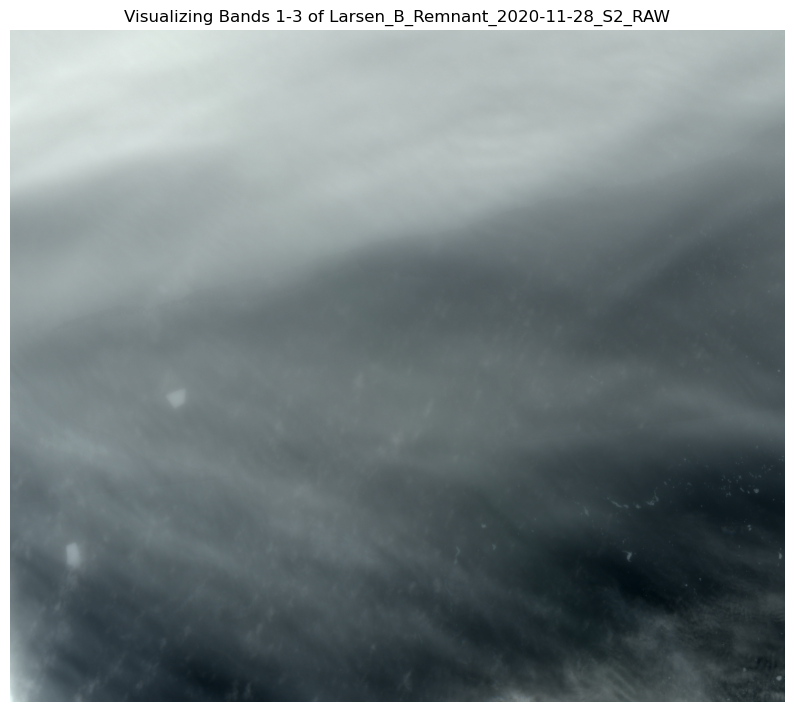

In [6]:
# 1. Load the master CSV you just created
metadata_csv_path = base_dir / "data/raw/datasets/metadata.csv"
df = pd.read_csv(metadata_csv_path)

# 2. Find a sample image to test
sample_row = df.sample(1).iloc[0]
image_path = sample_row['image_path']

print(f"Loading test image: {image_path}")

# 3. Open with rasterio and CHECK THE BANDS
try:
    with rasterio.open(image_path) as src:
        print(f"\n--- CRITICAL CHECK ---")
        print(f"Band Count (src.count):   {src.count}")
        print(f"Band Indexes (src.indexes): {src.indexes}")
        
        # This will list the band names if they are stored in the file
        print(f"Band Descriptions:      {src.descriptions}")
        print(f"Image CRS (Projection):   {src.crs}")
        print(f"----------------------\n")

        # 4. Try to plot the first 3 bands for a visual
        if src.count >= 3:
            # Read the first 3 bands (e.g., Blue, Green, Red for Landsat/Sentinel)
            b1 = src.read(1)
            b2 = src.read(2)
            b3 = src.read(3)

            # Stack them for plotting
            img_data = np.dstack((b1, b2, b3))
            
            # Simple normalization for plotting
            img_data = (img_data - np.nanmin(img_data)) / (np.nanmax(img_data) - np.nanmin(img_data))

            plt.figure(figsize=(10, 10))
            plt.imshow(img_data)
            plt.title(f"Visualizing Bands 1-3 of {sample_row['basename']}")
            plt.axis('off')
            plt.show()
        else:
            print("Image has less than 3 bands, cannot plot.")

except Exception as e:
    print(f"ERROR: Could not open image {image_path}")
    print(e)